## **Problem Statement**

The company aims to evaluate the selling performance of its products by analyzing customer buying behavior. Due to the large size of the dataset, traditional manual analysis methods are impractical. The objective is to segment customers into distinct groups based on their purchasing patterns using clustering techniques. This segmentation will help the company understand different customer profiles, enabling more targeted marketing strategies and improving product offerings.




In [ ]:
#from google.colab import drive
#drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, LabelEncoder
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
import warnings
warnings.filterwarnings('ignore')


In [5]:
import warnings
warnings.filterwarnings('ignore')

In [6]:
# Load data
customers = pd.read_excel('/content/Online Retail.xlsx')


In [ ]:
customers.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [ ]:
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [ ]:
# Data cleaning
customers = customers.drop(columns=['StockCode', 'Description', 'InvoiceDate', 'CustomerID', 'InvoiceNo'], axis=1)


In [7]:
customers = customers.sample(n=4000, random_state=42)


In [8]:
customers = customers.dropna()

In [9]:
# Preprocessing
X = customers[['Quantity', 'UnitPrice']]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [10]:
# Encoding Categorical variables
countries = customers['Country']
label_encoder = LabelEncoder()
countries_encoded = label_encoder.fit_transform(countries).reshape(-1, 1)

In [11]:
X_scaled_with_countries = np.concatenate((X_scaled, countries_encoded), axis=1)

In [12]:
# Perform hierarchical clustering (Agglomerative Clustering)
linked = linkage(X_scaled_with_countries, method='ward')

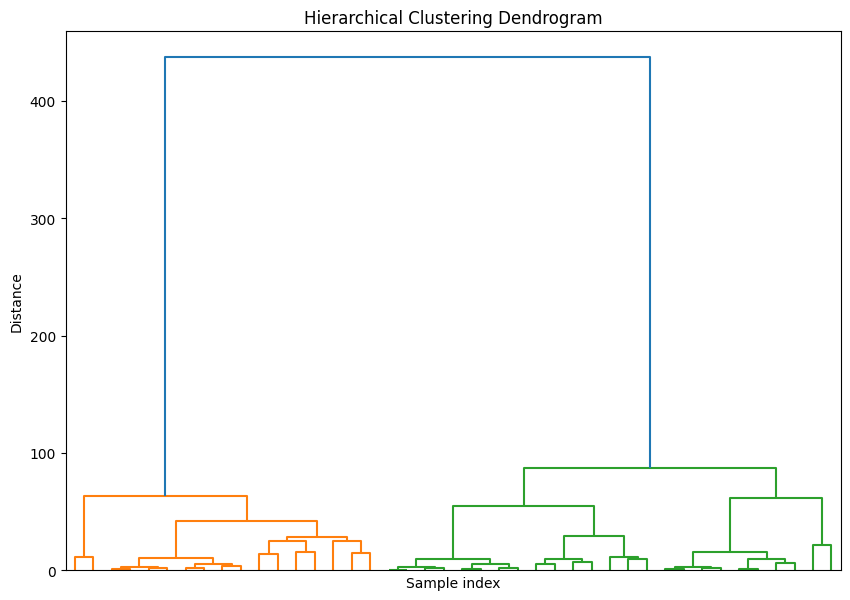

In [13]:
# Plot dendrogram
plt.figure(figsize=(10, 7))
dendrogram(linked, orientation='top', truncate_mode='level', p=5, no_labels=True)
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Sample index')
plt.ylabel('Distance')
plt.show()


In [15]:
agg_clustering = AgglomerativeClustering(n_clusters=5, linkage='ward')
clusters = agg_clustering.fit_predict(X_scaled_with_countries)


In [16]:
score = silhouette_score(X_scaled_with_countries, clusters)

In [17]:
print("Agglomerative Clustering Silhouette score:", score)

Agglomerative Clustering Silhouette score: 0.9017703780872147


### Using the Elbow Method

In [18]:
# Load data
customers = pd.read_excel('/content/Online Retail.xlsx')


In [19]:
# Data cleaning
customers = customers.drop(columns=['StockCode', 'Description', 'InvoiceDate', 'CustomerID', 'InvoiceNo'], axis=1)
customers = customers.sample(n=4000, random_state=42)
customers = customers.dropna()


In [ ]:
# Preprocessing
X = customers[['Quantity', 'UnitPrice']]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [ ]:
countries = customers['Country']
label_encoder = LabelEncoder()
countries_encoded = label_encoder.fit_transform(countries).reshape(-1, 1)

In [ ]:
X_scaled_with_countries = np.concatenate((X_scaled, countries_encoded), axis=1)


In [ ]:
# Perform hierarchical clustering (Agglomerative Clustering)
linked = linkage(X_scaled_with_countries, method='ward')

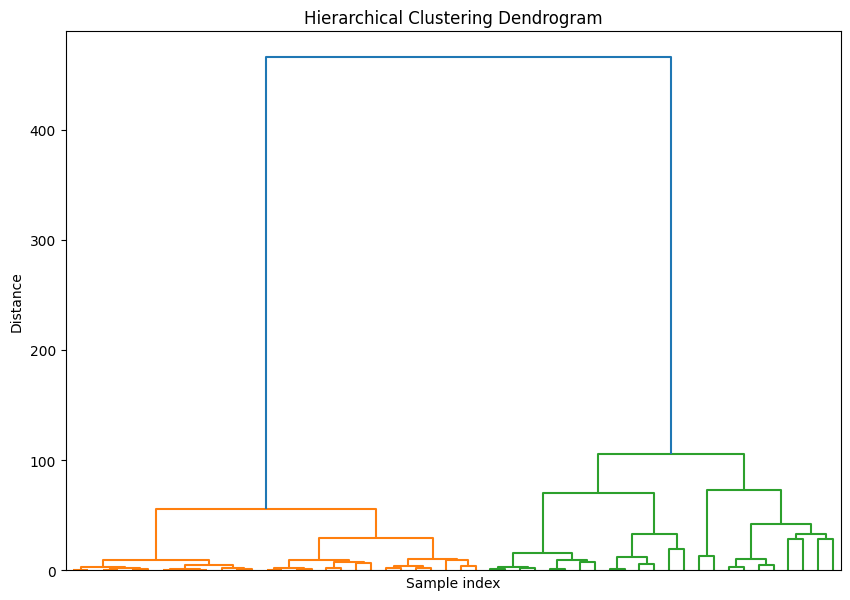

In [ ]:
# Plot dendrogram
plt.figure(figsize=(10, 7))
dendrogram(linked, orientation='top', truncate_mode='level', p=5, no_labels=True)
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Sample index')
plt.ylabel('Distance')
plt.show()


In [ ]:
# Silhouette Score Calculation
silhouette_scores = []

for nr_c in range(2, 16):  # Start from 2 clusters, as silhouette score requires at least 2 clusters
    agglomerative = AgglomerativeClustering(n_clusters=nr_c)
    agglomerative_labels = agglomerative.fit_predict(X_scaled_with_countries)
    silhouette_scores.append(silhouette_score(X_scaled_with_countries, agglomerative_labels))

In [ ]:
# Elbow method
cluster_range = range(2, 16)
silhouette_scores_subset = silhouette_scores[:14]  # Take subset as silhouette scores are calculated from 2 to 15 clusters


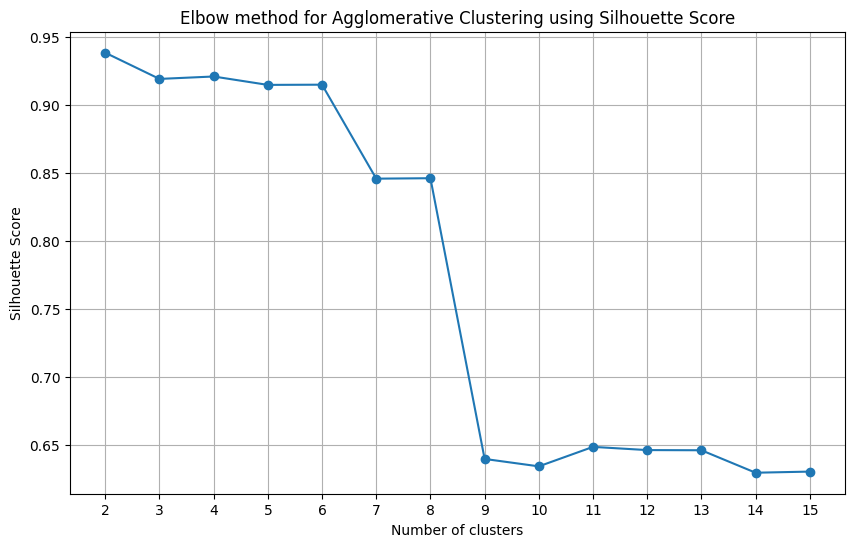

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(cluster_range, silhouette_scores_subset, marker='o')
plt.title('Elbow method for Agglomerative Clustering using Silhouette Score')
plt.xlabel('Number of clusters')
plt.ylabel('Silhouette Score')
plt.xticks(np.arange(2, 16, step=1))  # Adjust ticks for better visualization
plt.grid(True)
plt.show()



In [ ]:
# Find the optimal number of clusters
optimal_clusters = silhouette_scores.index(max(silhouette_scores)) + 2  # Add 2 as we started from 2 clusters
print("Optimal number of clusters:", optimal_clusters)



Optimal number of clusters: 2


In [ ]:
# Agglomerative Clustering with optimal number of clusters
agglomerative = AgglomerativeClustering(n_clusters=optimal_clusters)
agglomerative_labels = agglomerative.fit_predict(X_scaled_with_countries)



In [ ]:
# Silhouette score for Agglomerative Clustering
agglomerative_score = silhouette_score(X_scaled_with_countries, agglomerative_labels)
print("Agglomerative Clustering Silhouette score:", agglomerative_score)


Agglomerative Clustering Silhouette score: 0.9384088926440506
